In [2]:
!pip install -q pyomo
!apt-get install -y -qq glpk-utils

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 25.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 4.4 MB/s eta 0:00:00
Selecting previously unselected package libsuitesparseconfig5:amd64.
(Reading database ... 121752 files and directories currently installed.)
Preparing to unpack .../libsuitesparseconfig5_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libsuitesparseconfig5:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libamd2:amd64.
Preparing to unpack .../libamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libcolamd2:amd64.
Preparing to unpack .../libcolamd2_1%3a5.10.1+dfsg-4build1_amd64.deb ...
Unpacking libcolamd2:amd64 (1:5.10.1+dfsg-4build1) ...
Selecting previously unselected package libglpk40:amd64.
Preparing to unpack .../libglpk40_5.0-1_amd64.deb ...
Unpacking libglpk40:amd64 (5.0-1) ...
Selecting previously unselected pac

In [83]:
from pyomo.environ import *

def create_tsp_model(num_cities, distance_matrix):
    model = ConcreteModel()

    # Set of nodes
    model.N = RangeSet(1, num_cities)

    # Binary decision variables: x[i,j] equals 1 if the TSP tour goes from node i to node j
    model.x = Var(model.N, model.N, within=Binary, initialize=0)

    # Continuous decision variables: u[i] represents the order of node i in the tour
    model.u = Var(RangeSet(2, num_cities), within=Reals)

    # Objective function: minimize total distance
    model.obj = Objective(expr=sum(distance_matrix[i, j] * model.x[i, j] for i in model.N for j in model.N if i != j), sense=minimize)

    # Constraints
    def exactly_one_outgoing_arc_rule(model, i):
        return sum(model.x[i, j] for j in model.N if j != i) == 1

    model.exactly_one_outgoing_arc = Constraint(model.N, rule=exactly_one_outgoing_arc_rule)

    def exactly_one_incoming_arc_rule(model, i):
        return sum(model.x[j, i] for j in model.N if j != i) == 1

    model.exactly_one_incoming_arc = Constraint(model.N, rule=exactly_one_incoming_arc_rule)

    def no_self_arc_rule(model, i):
        return model.x[i, i] == 0
    model.no_self_arc = Constraint(model.N, rule=no_self_arc_rule)

    def mtz_subtour_elimination_rule(model, i, j):
        if i != j and j != 1 and i != 1:
            return model.u[i] - model.u[j] + 1 <= (num_cities - 1)*(1 - model.x[i,j])
        else:
            return Constraint.Skip
    model.mtz_subtour_elimination = Constraint(model.N, model.N, rule=mtz_subtour_elimination_rule)

    return model

def solve_tsp(model, tee=False):
    solver = SolverFactory('glpk')
    solver.solve(model, tee=tee)
    return model

def print_solution(model):
    for i in model.N:
        for j in model.N:
            if value(model.x[i, j]) == 1:
              print(f"Node {i} -> Node {j}")
    print(f"Optimal distance: {value(model.obj)}")

# Example usage
num_cities = 4
distance_matrix = {
    (1, 2): 10, (1, 3): 15, (1, 4): 20,
    (2, 1): 10, (2, 3): 35, (2, 4): 25,
    (3, 1): 15, (3, 2): 35, (3, 4): 30,
    (4, 1): 20, (4, 2): 25, (4, 3): 30
}

model = create_tsp_model(num_cities, distance_matrix)
solve_tsp(model, tee=True)
model.pprint()
model.display()
print_solution(model)

GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpv53tvj5q.glpk.raw --wglp /tmp/tmpay1apg22.glpk.glp --cpxlp
 /tmp/tmpwf9oiriw.pyomo.lp
Reading problem data from '/tmp/tmpwf9oiriw.pyomo.lp'...
/tmp/tmpwf9oiriw.pyomo.lp:141: warning: lower bound of variable 'x23' redefined
/tmp/tmpwf9oiriw.pyomo.lp:141: warning: upper bound of variable 'x23' redefined
18 rows, 19 columns, 46 non-zeros
16 integer variables, all of which are binary
157 lines were read
Writing problem data to '/tmp/tmpay1apg22.glpk.glp'...
115 lines were written
GLPK Integer Optimizer 5.0
18 rows, 19 columns, 46 non-zeros
16 integer variables, all of which are binary
Preprocessing...
14 rows, 15 columns, 42 non-zeros
12 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  3.000e+00  ratio =  3.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of triangular part is 13
Solving LP relaxation...
GLPK Simplex Optimizer

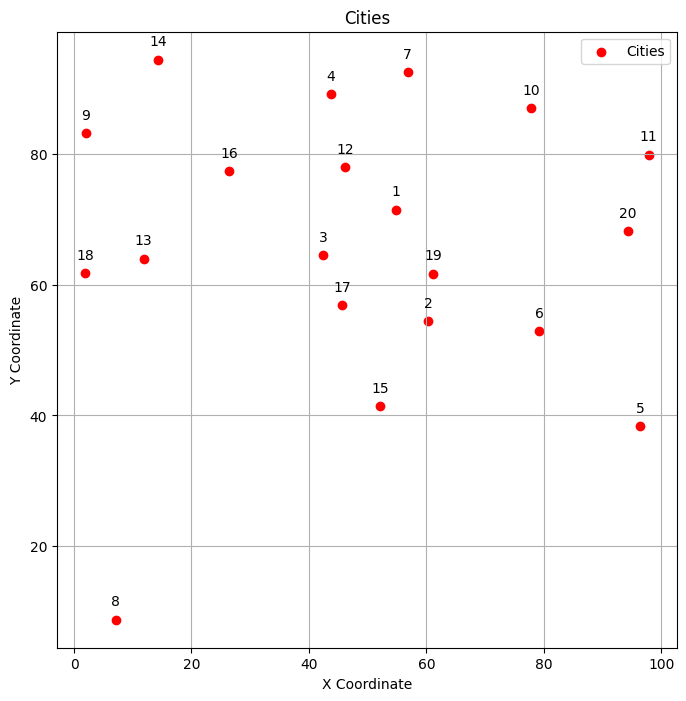

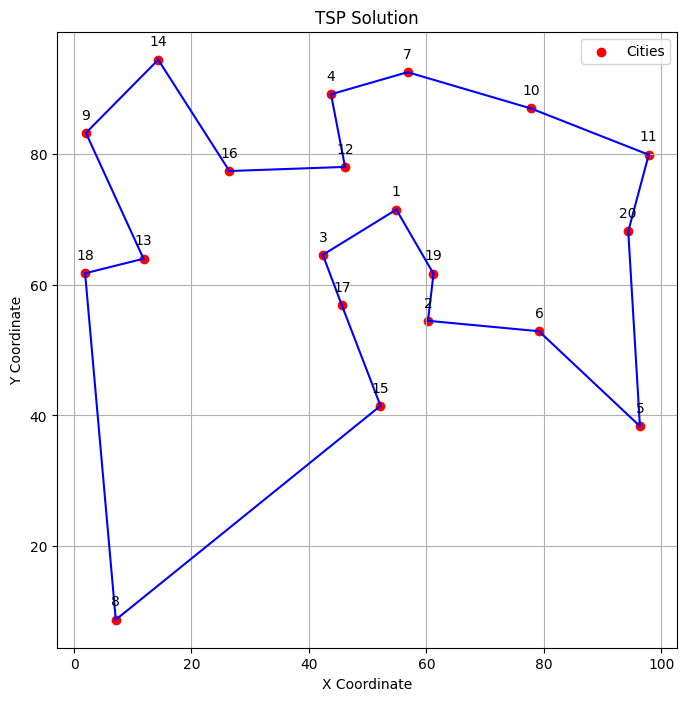

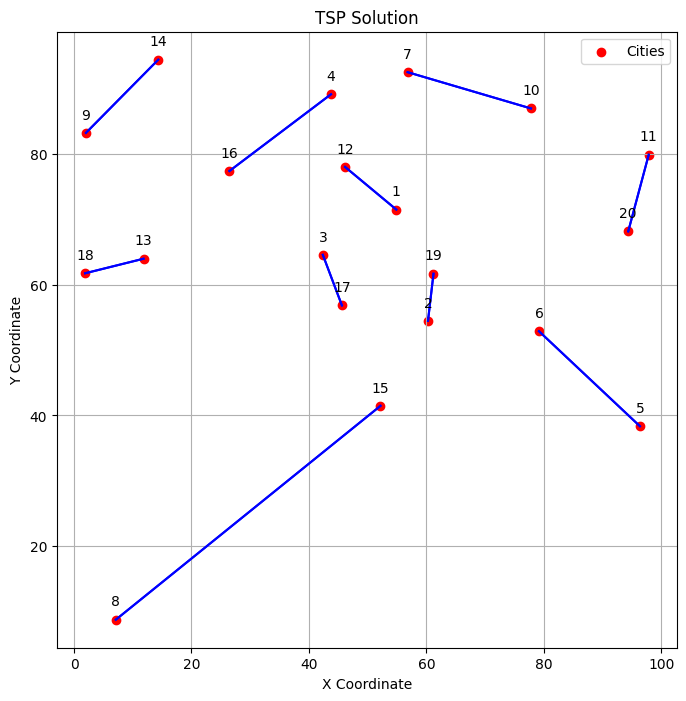

In [81]:
import numpy as np
import matplotlib.pyplot as plt

def generate_random_points(num_cities):
    np.random.seed(0)
    # Generate random coordinates for each city
    city_coordinates = np.random.rand(num_cities, 2) * 100  # Assuming a 100x100 grid for simplicity
    return city_coordinates

def compute_distance_matrix(city_coordinates):
    num_cities = len(city_coordinates)
    distance_matrix = {}

    for i in range(num_cities):
        for j in range(num_cities):
            if i != j:
                distance_matrix[(i+1, j+1)] = np.linalg.norm(city_coordinates[i] - city_coordinates[j])  # Euclidean distance

    return distance_matrix


def plot_cities(city_coordinates):
    plt.figure(figsize=(8, 8))
    plt.scatter(city_coordinates[:, 0], city_coordinates[:, 1], c='red', label='Cities')
    for i, (x, y) in enumerate(city_coordinates):
        plt.annotate(f"{i+1}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')
    plt.title('Cities')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_tsp_solution(city_coordinates, model):
  plt.figure(figsize=(8, 8))
  plt.scatter(city_coordinates[:, 0], city_coordinates[:, 1], c='red', label='Cities')
  for i, (x, y) in enumerate(city_coordinates):
      plt.annotate(f"{i+1}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')

  # Plot the edges representing the TSP tour
  for i in model.N:
      for j in model.N:
          if value(model.x[i, j]) == 1:
              plt.plot([city_coordinates[i-1, 0], city_coordinates[j-1, 0]],
                        [city_coordinates[i-1, 1], city_coordinates[j-1, 1]], 'b-')

  plt.title('TSP Solution')
  plt.xlabel('X Coordinate')
  plt.ylabel('Y Coordinate')
  plt.grid(True)
  plt.legend()
  plt.show()

# Example usage:
num_cities = 20
city_coordinates = generate_random_points(num_cities)
distance_matrix = compute_distance_matrix(city_coordinates)
model = create_tsp_model(num_cities, distance_matrix)
solve_tsp(model)

plot_cities(city_coordinates)
plot_tsp_solution(city_coordinates, model)
model.mtz_subtour_elimination.deactivate()
solve_tsp(model)
plot_tsp_solution(city_coordinates, model)



Best solution: [31, 8, 33, 25, 21, 15, 2, 19, 7, 4, 1, 12, 3, 16, 14, 9, 18, 13, 17, 23, 10, 11, 20, 6, 26, 29, 32, 22, 34, 35, 27, 5, 30, 28, 24]
Best fitness: 625.1638912445254


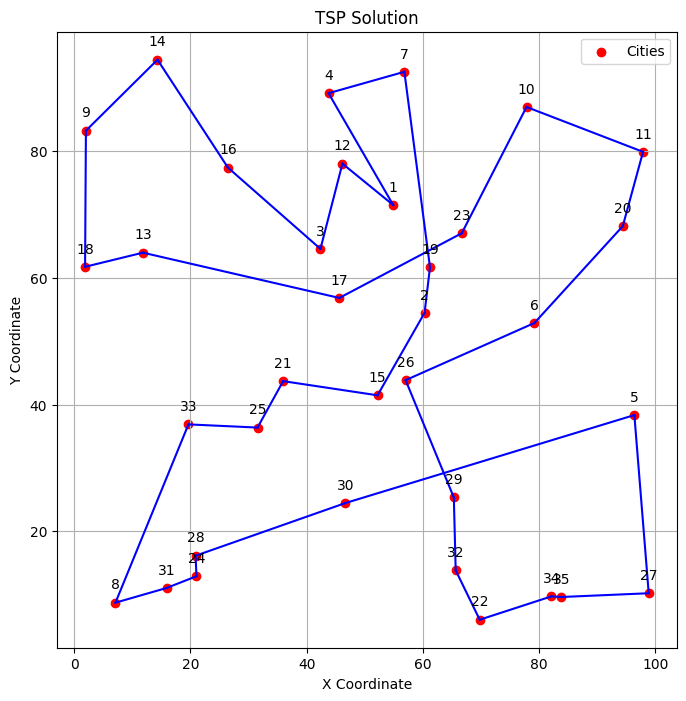

In [52]:
import numpy as np
import random

def generate_random_population(num_individuals, num_cities):
    return [random.sample(range(1, num_cities + 1), num_cities) for _ in range(num_individuals)]

def compute_fitness(individual, distance_matrix):
    fitness = 0
    num_cities = len(individual)
    for i in range(num_cities - 1):
        fitness += distance_matrix[(individual[i], individual[i+1])]
    fitness += distance_matrix[(individual[-1], individual[0])]  # Complete the tour
    return fitness

def tournament_selection(population, distance_matrix, tournament_size):
    selected_parents = []
    for _ in range(len(population)):
        tournament = random.sample(population, tournament_size)
        selected_parents.append(min(tournament, key=lambda x: compute_fitness(x, distance_matrix)))
    return selected_parents

def ordered_crossover(parent1, parent2):
    size = len(parent1)
    offspring1, offspring2 = [-1] * size, [-1] * size
    start, end = sorted(random.sample(range(size), 2))
    offspring1[start:end] = parent1[start:end]
    offspring2[start:end] = parent2[start:end]

    p1_indices, p2_indices = set(parent1[start:end]), set(parent2[start:end])
    p1_remaining, p2_remaining = [x for x in parent2 if x not in p1_indices], [x for x in parent1 if x not in p2_indices]

    offspring1[end:] = [x for x in p1_remaining if x not in offspring1]
    offspring1[:start] = [x for x in p1_remaining if x not in offspring1]

    offspring2[end:] = [x for x in p2_remaining if x not in offspring2]
    offspring2[:start] = [x for x in p2_remaining if x not in offspring2]

    return offspring1, offspring2

def swap_mutation(individual):
    idx1, idx2 = random.sample(range(len(individual)), 2)
    individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
    return individual

def genetic_algorithm(num_cities, distance_matrix, population_size, num_generations, tournament_size, crossover_rate, mutation_rate):
    population = generate_random_population(population_size, num_cities)
    for _ in range(num_generations):
        parents = tournament_selection(population, distance_matrix, tournament_size)
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[i+1]
            if random.random() < crossover_rate:
                child1, child2 = ordered_crossover(parent1, parent2)
            else:
                child1, child2 = parent1[:], parent2[:]
            if random.random() < mutation_rate:
                child1 = swap_mutation(child1)
            if random.random() < mutation_rate:
                child2 = swap_mutation(child2)
            offspring.append(child1)
            offspring.append(child2)
        population = sorted(population + offspring, key=lambda x: compute_fitness(x, distance_matrix))[:population_size]
    best_solution = min(population, key=lambda x: compute_fitness(x, distance_matrix))
    best_fitness = compute_fitness(best_solution, distance_matrix)
    return best_solution, best_fitness

def plot_tsp_solution_ga(city_coordinates, best_solution):
    plt.figure(figsize=(8, 8))
    plt.scatter(city_coordinates[:, 0], city_coordinates[:, 1], c='red', label='Cities')
    for i, (x, y) in enumerate(city_coordinates):
        plt.annotate(f"{i+1}", (x, y), textcoords="offset points", xytext=(0,10), ha='center')

    # Plot the edges representing the TSP tour
    for i in range(len(best_solution)):
        city1 = best_solution[i]
        city2 = best_solution[(i + 1) % len(best_solution)]  # Connect back to the first city
        plt.plot([city_coordinates[city1-1, 0], city_coordinates[city2-1, 0]],
                 [city_coordinates[city1-1, 1], city_coordinates[city2-1, 1]], 'b-')

    plt.title('TSP Solution')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.legend()
    plt.show()

# Example usage:
num_cities = 35
city_coordinates = generate_random_points(num_cities)
distance_matrix = compute_distance_matrix(city_coordinates)
population_size = 100
num_generations = 200
tournament_size = 5
crossover_rate = 0.7
mutation_rate = 0.2

best_solution, best_fitness = genetic_algorithm(num_cities, distance_matrix, population_size, num_generations, tournament_size, crossover_rate, mutation_rate)

print("Best solution:", best_solution)
print("Best fitness:", best_fitness)

# Example usage:
plot_tsp_solution_ga(city_coordinates, best_solution)
